In [1]:
#Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

In [3]:
#Reading the excel file
data=pd.read_excel("Mall_Customers.xlsx")

In [4]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.corr(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


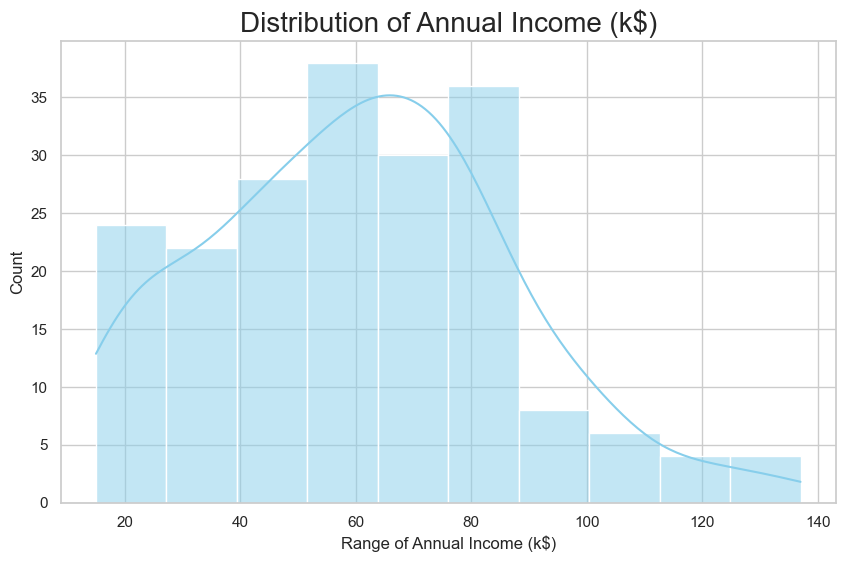

In [6]:
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid')
sns.histplot(data['Annual Income (k$)'], kde=True, color='skyblue')
plt.title('Distribution of Annual Income (k$)', fontsize=20)
plt.xlabel('Range of Annual Income (k$)')
plt.ylabel('Count')
plt.show()

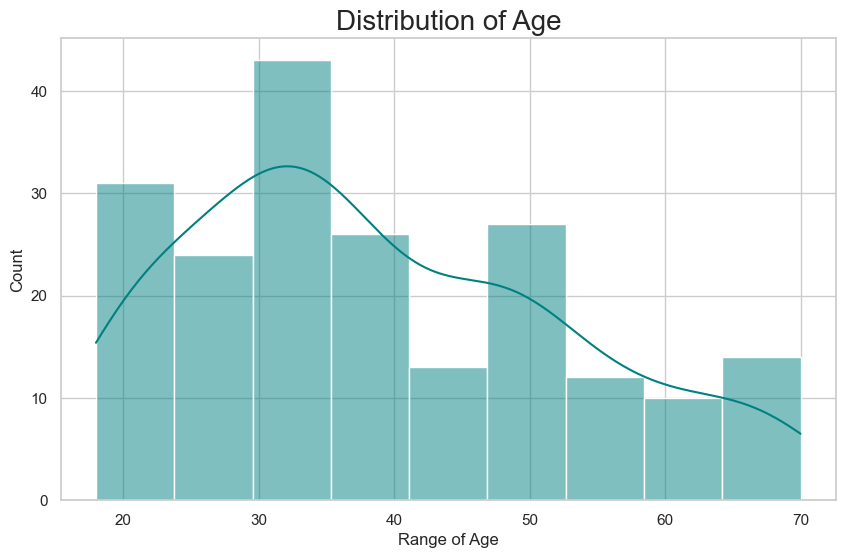

In [7]:
#Distribution of age
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid')
sns.histplot(data['Age'], kde=True, color='teal')
plt.title('Distribution of Age', fontsize=20)
plt.xlabel('Range of Age')
plt.ylabel('Count')
plt.show()

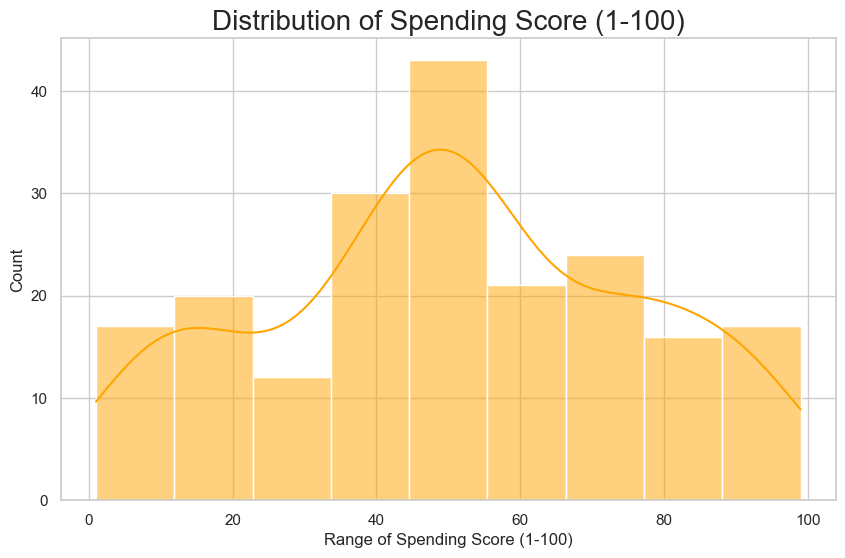

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid')
sns.histplot(data['Spending Score (1-100)'], kde=True, color='orange')
plt.title('Distribution of Spending Score (1-100)', fontsize=20)
plt.xlabel('Range of Spending Score (1-100)')
plt.ylabel('Count')
plt.show()

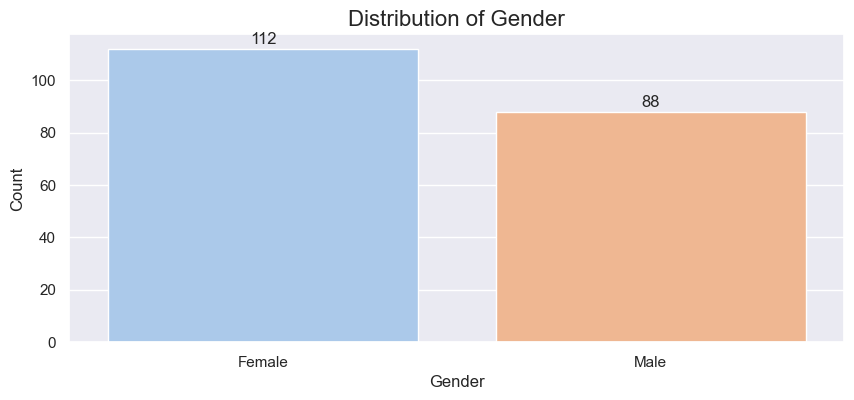

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
genders = data["Gender"].value_counts()
sns.set_style("darkgrid")
plt.figure(figsize=(10,4))
sns.barplot(x=genders.index,
 y=genders.values,
 hue=genders.index,
 dodge=False,
 legend=False,
 palette="pastel")
plt.title("Distribution of Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")
# Add value labels on bars
for i, val in enumerate(genders.values):
 plt.text(i, val + 2, str(val), ha='center', fontsize=12)
plt.show()

In [11]:
# We take just the Annual Income and Spending Score
df1 = data[["CustomerID", "Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# The input data
X = df1[["Annual Income (k$)", "Spending Score (1-100)"]]

# Display the first 5 rows
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


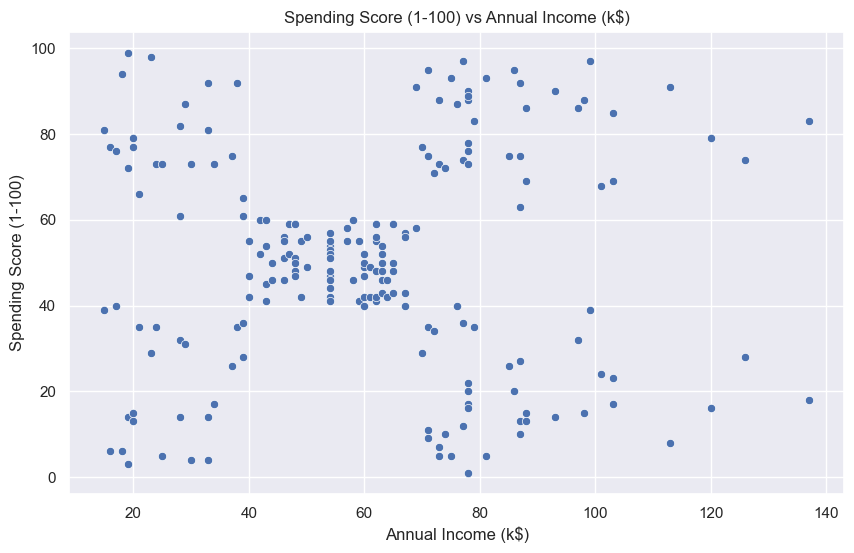

In [12]:
# Scatterplot of the input data
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                data=X)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()

In [13]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

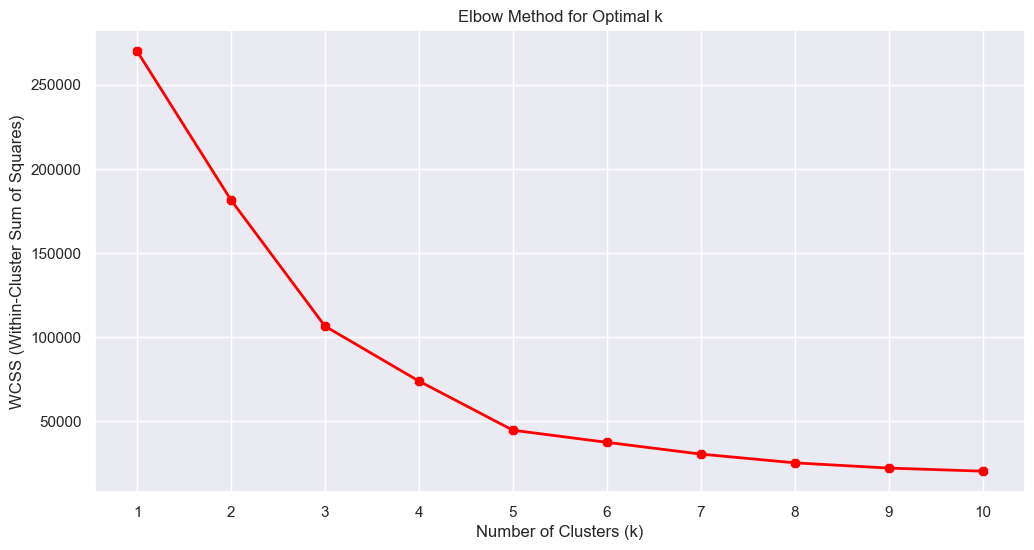

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
wcss = []
for i in range(1, 11):
 km = KMeans(n_clusters=i, n_init=10, random_state=42)
 km.fit(X)
 wcss.append(km.inertia_)
 # The elbow curve
plt.figure(figsize=(12,6))
plt.plot(range(1,11), wcss, linewidth=2, color="red", marker="8")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(np.arange(1, 11, 1))
plt.show()

In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [17]:
#Taking 5 clusters
km1=KMeans(n_clusters=5)
#Fitting the input data
km1.fit(X)
#predicting the labels of the input data
y=km1.predict(X)
#adding the labels to a column named label
df1["label"] = y
#The new dataframe with the clustering done
df1.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),label
0,1,Male,19,15,39,0
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,0


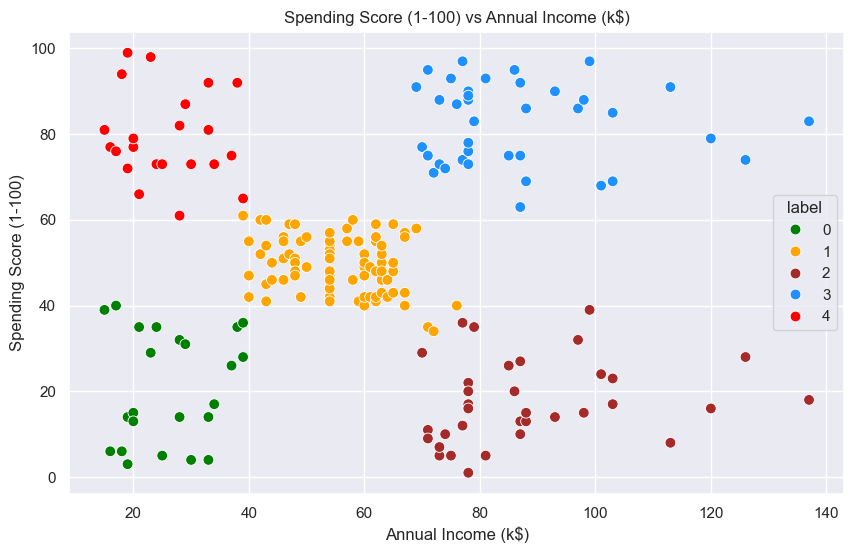

In [20]:
# Scatterplot of the clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                hue='label',   # <-- column in df1 with cluster labels
                palette=['green','orange','brown','dodgerblue','red'],
                legend='full', 
                data=df1, 
                s=60)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.show()

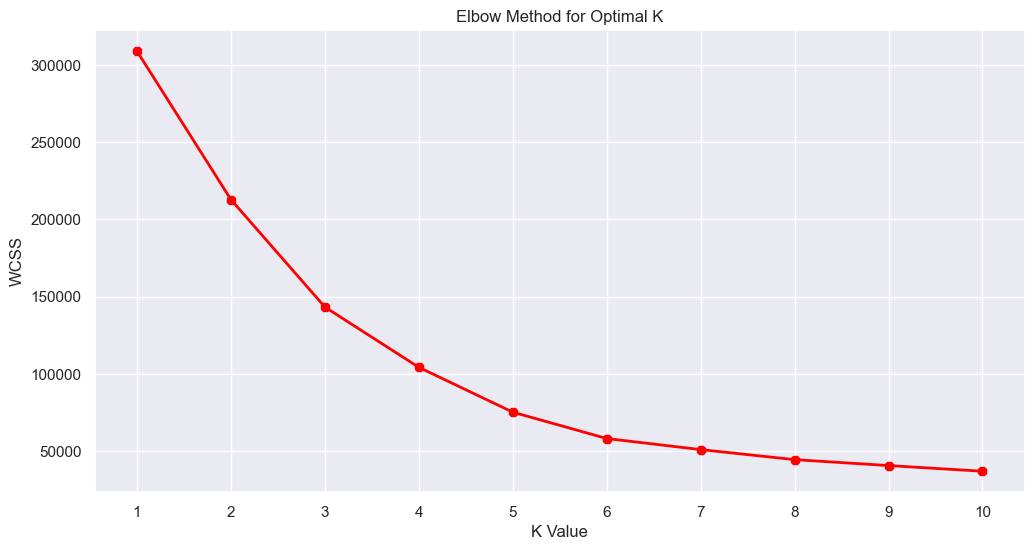

In [21]:
# Taking the features
df2 = data[["CustomerID","Gender","Age","Annual Income (k$)","Spending Score (1-100)"]]
X2 = df2[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Now we calculate the Within Cluster Sum of Squared Errors (WCSS) for different values of k
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X2)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(12,6))
plt.plot(range(1, 11), wcss, linewidth=2, color="red", marker="8")
plt.xlabel("K Value")
plt.xticks(np.arange(1, 11, 1))
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [22]:
#We choose the k for which WSS starts to diminish
km2 = KMeans(n_clusters=5)
y2 = km.fit_predict(X2)
df2["label"] = y2
#The data with labels
df2.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),label
0,1,Male,19,15,39,6
1,2,Male,21,15,81,3
2,3,Female,20,16,6,0
3,4,Female,23,16,77,3
4,5,Female,31,17,40,6


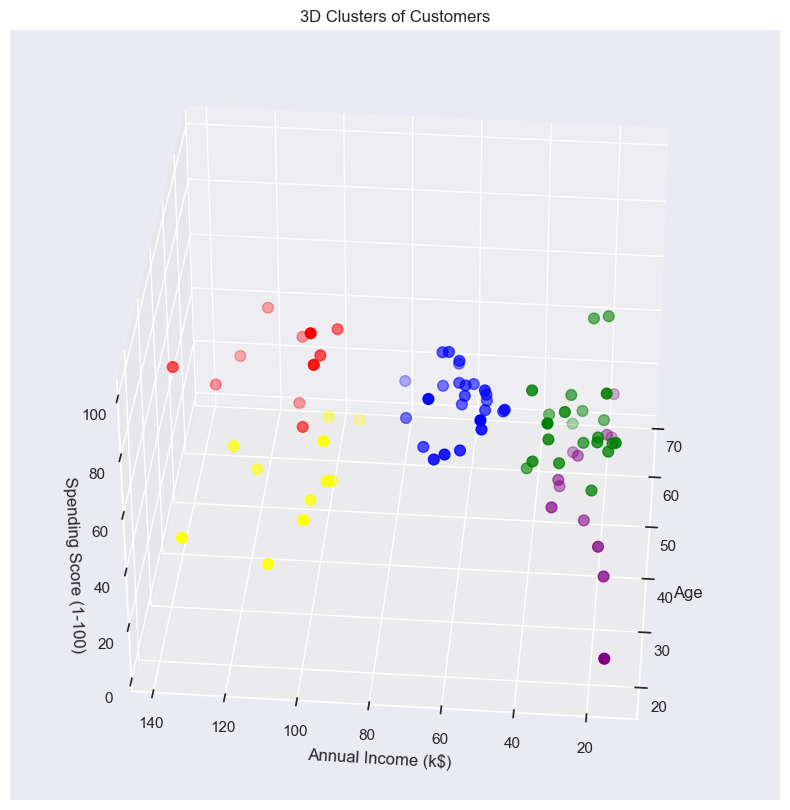

In [24]:
# 3D Plot as we did the clustering on the basis of 3 input features
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df2.Age[df2.label == 0], 
           df2["Annual Income (k$)"][df2.label == 0], 
           df2["Spending Score (1-100)"][df2.label == 0], 
           c='purple', s=60)

ax.scatter(df2.Age[df2.label == 1], 
           df2["Annual Income (k$)"][df2.label == 1], 
           df2["Spending Score (1-100)"][df2.label == 1], 
           c='red', s=60)

ax.scatter(df2.Age[df2.label == 2], 
           df2["Annual Income (k$)"][df2.label == 2], 
           df2["Spending Score (1-100)"][df2.label == 2], 
           c='blue', s=60)

ax.scatter(df2.Age[df2.label == 3], 
           df2["Annual Income (k$)"][df2.label == 3], 
           df2["Spending Score (1-100)"][df2.label == 3], 
           c='green', s=60)

ax.scatter(df2.Age[df2.label == 4], 
           df2["Annual Income (k$)"][df2.label == 4], 
           df2["Spending Score (1-100)"][df2.label == 4], 
           c='yellow', s=60)

# Set view angle
ax.view_init(35, 185)

# Labels
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
ax.set_zlabel('Spending Score (1-100)')

plt.title("3D Clusters of Customers")
plt.show()


In [25]:
cust1=df1[df1["label"]==1]
print('Number of customer in 1st group=', len(cust1))
print('They are -', cust1["CustomerID"].values)
print("....................................... ")
cust2=df1[df1["label"]==2]
print('Number of customer in 2nd group=', len(cust2))
print('They are -', cust2["CustomerID"].values)
print("....................................... ")
cust3=df1[df1["label"]==3]
print('Number of customer in 3rd group=', len(cust3))
print('They are -', cust3["CustomerID"].values)
print("........................................")
cust4=df1[df1["label"]==4]
print('Number of customer in 4rth group=', len(cust3))
print('They are -', cust4["CustomerID"].values)
print("........................................")
cust5=df1[df1["label"]==5]
print('Number of customer in 5th group=', len(cust3))
print('They are -', cust5["CustomerID"].values)
print(".........................................")

Number of customer in 1st group= 81
They are - [ 44  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63
  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81
  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99
 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 127 133 143]
....................................... 
Number of customer in 2nd group= 35
They are - [125 129 131 135 137 139 141 145 147 149 151 153 155 157 159 161 163 165
 167 169 171 173 175 177 179 181 183 185 187 189 191 193 195 197 199]
....................................... 
Number of customer in 3rd group= 39
They are - [124 126 128 130 132 134 136 138 140 142 144 146 148 150 152 154 156 158
 160 162 164 166 168 170 172 174 176 178 180 182 184 186 188 190 192 194
 196 198 200]
........................................
Number of customer in 4rth group= 39
They are - [ 2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 

In [26]:
cust1=df2[df2["label"]==1]
print('Number of customer in 1st group=', len(cust1))
print('They are -', cust1["CustomerID"].values)
print("....................................... ")
cust2=df2[df2["label"]==2]
print('Number of customer in 2nd group=', len(cust2))
print('They are -', cust2["CustomerID"].values)
print("....................................... ")
cust3=df2[df2["label"]==3]
print('Number of customer in 3rd group=', len(cust3))
print('They are -', cust3["CustomerID"].values)
print("........................................")
cust4=df2[df2["label"]==4]
print('Number of customer in 4rth group=', len(cust3))
print('They are -', cust4["CustomerID"].values)
print("........................................")
cust5=df2[df2["label"]==5]
print('Number of customer in 5th group=', len(cust3))
print('They are -', cust5["CustomerID"].values)
print(".........................................")

Number of customer in 1st group= 11
They are - [180 182 184 186 188 190 192 194 196 198 200]
....................................... 
Number of customer in 2nd group= 25
They are - [ 67  72  77  78  80  82  84  86  90  93  94  97  99 102 105 108 113 118
 119 120 122 123 127 147 161]
....................................... 
Number of customer in 3rd group= 22
They are - [ 2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 46]
........................................
Number of customer in 4rth group= 22
They are - [179 181 183 185 187 189 191 193 195 197 199]
........................................
Number of customer in 5th group= 22
They are - [ 44  48  52  53  59  62  66  69  70  76  79  85  88  89  92  95  96  98
 100 101 104 106 112 114 115 116 121 133 143]
.........................................
